Potencia de ruido (pr): 0.030990


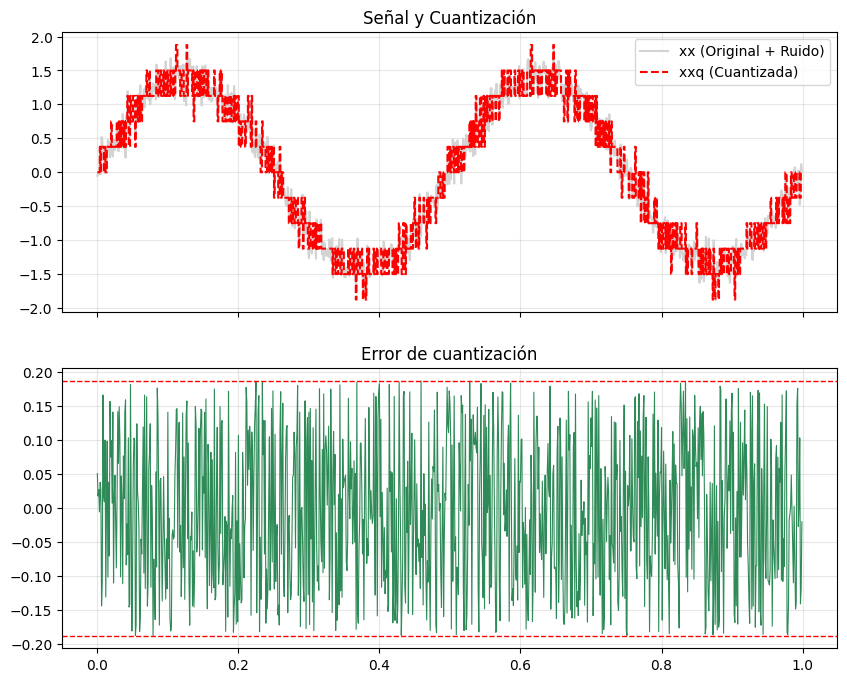

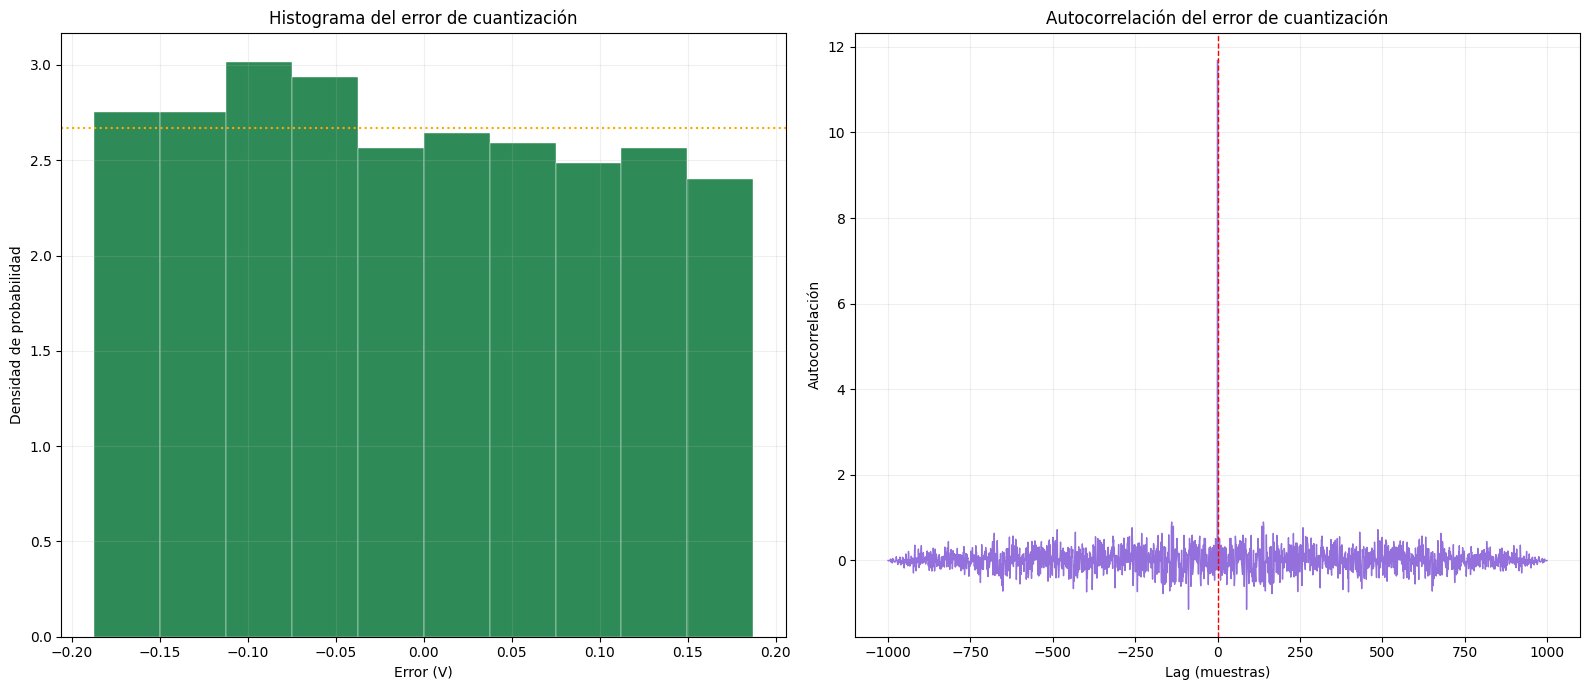

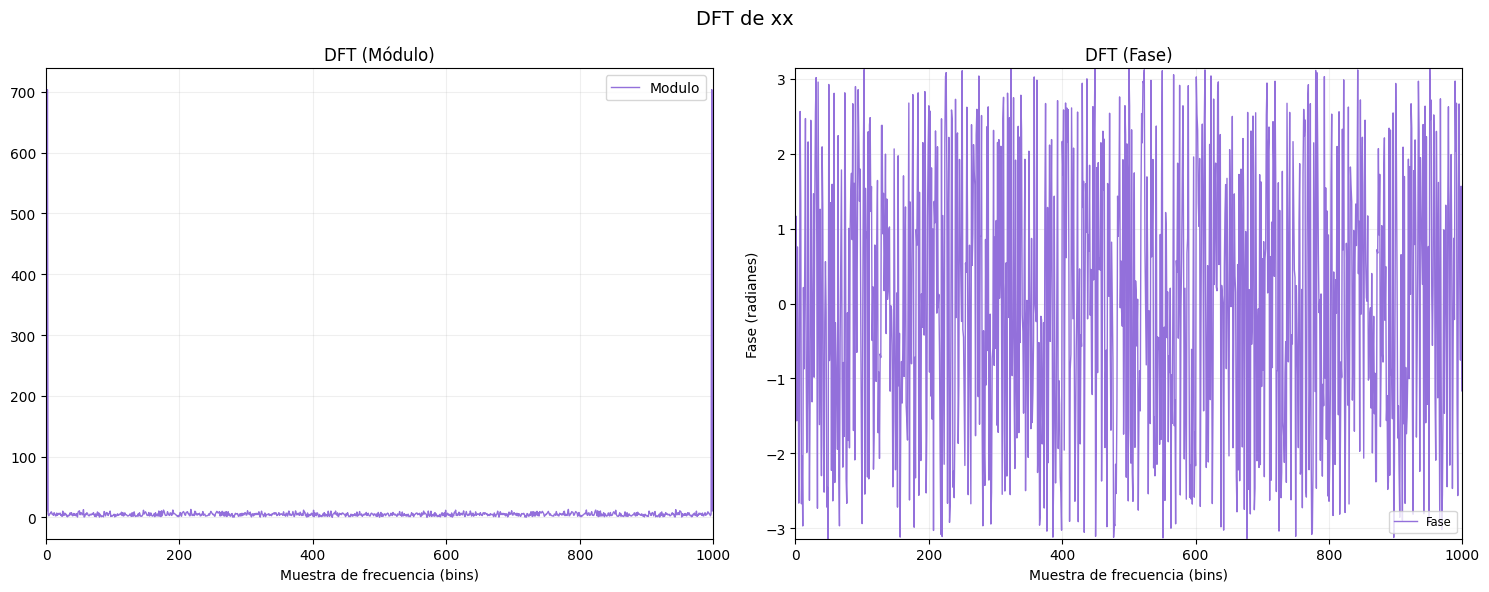

--------------------------------------------------
ANÁLISIS DE LA DFT:
Amplitud máxima en el módulo: 703.4
Muestra de frecuencia (bin) del pico: 2
--------------------------------------------------


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen_ruido(vmax, dc, ff, ph, nn, fs, pr):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    desvio = np.sqrt(pr)
    r = np.random.normal(0, desvio, len(tt)) 
    
    print(f"Potencia de ruido (pr): {pr:.6f}") 
    # Generamos la señal con ruido
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    xx_con_ruido = xx + r
    return tt, xx_con_ruido

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(nn) * ts
    
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    
    return tt, xx


# --- 1. Configuración de parámetros ---
fs = 1000
N = 1000                    # Aumenté N a 1000 para que dure 1 segundo como tu linspace
B = 3                       # Bits de cuantización
Vfs = 3                     # Voltaje Fondo de Escala
vmax = 1 
q = Vfs / (2**B)            # Paso de cuantización (LSB)

A = 1.4                     # Amplitud
dc = 0
f1 = 2                      # 2 Hz para que se vea mejor en 1 segundo
fase = 0
snr = 15               # dB

Ps = (A**2)/ 2              # Potencia de la señal
pr = Ps / (10**(snr/10))    # Potencia de ruido (Varianza)

# --- 2. Generación de señales ---
# tt1 y xx1 ya contienen la señal base + el ruido
tt1, xx = mi_funcion_sen_ruido(A, dc, f1, fase, N, fs, pr)

# Cuantización
xxq = np.round(xx / q) * q
ee = xxq - xx

# --- 3. Graficación: Señal y Error ---
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(tt1, xx, color='lightgray', label='xx (Original + Ruido)')
ax1.step(tt1, xxq, where='mid', color='red', linestyle='--', label='xxq (Cuantizada)')
ax1.set_title("Señal y Cuantización")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(tt1, ee, color='seagreen', linewidth=0.8)
ax2.axhline(q/2, color='red', linestyle='--', linewidth=1)
ax2.axhline(-q/2, color='red', linestyle='--', linewidth=1)
ax2.set_title("Error de cuantización")
ax2.grid(True, alpha=0.3)

# --- 4. Graficación: Análisis Estadístico (Histograma y Autocorrelación) ---
fig2, (ax_hist, ax_corr) = plt.subplots(1, 2, figsize=(16, 7))

# PANEL IZQUIERDO: Histograma con MUCHOS BINS
n, bins, patches = ax_hist.hist(ee, bins=10, density=True, color='#2e8b57', edgecolor='white', linewidth=0.3)
ax_hist.axhline(1/q, color='orange', linestyle=':', label='Uniforme teórica')
ax_hist.set_title("Histograma del error de cuantización")
ax_hist.set_xlabel("Error (V)")
ax_hist.set_ylabel("Densidad de probabilidad")
ax_hist.grid(True, alpha=0.2)

# PANEL DERECHO: Autocorrelación completa
ree = np.correlate(ee, ee, mode='full')
lags = np.arange(-len(ee) + 1, len(ee))

ax_corr.plot(lags, ree, color='#9370DB', linewidth=1) # Color lila como la imagen
ax_corr.axvline(0, color='red', linestyle='--', linewidth=1, label='Lag = 0')
ax_corr.set_title("Autocorrelación del error de cuantización")
ax_corr.set_xlabel("Lag (muestras)")
ax_corr.set_ylabel("Autocorrelación")
# Quitamos el set_xlim para que se vea TODO el rango de -1000 a 1000
ax_corr.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


# 1. Cálculo de la FFT (Transformada Rápida de Fourier, un algoritmo para la DFT)
# Usamos la señal con ruido 'xx' que definimos antes
XX = np.fft.fft(xx)
N = len(xx) # Debería ser 1000

# 2. Extracción de Módulo y Fase
Modulo = np.abs(XX) # Calculamos la magnitud (el valor absoluto)
Fase = np.angle(XX) # Calculamos el ángulo de fase (en radianes)

# 3. Graficación Estilo Figure 3
fig_dft, (ax_mod, ax_fase) = plt.subplots(1, 2, figsize=(15, 6))
fig_dft.suptitle('DFT de xx', fontsize=14)

# PANEL IZQUIERDO: Módulo
# Graficamos con el color lila/púrpura de la captura
ax_mod.plot(Modulo, color='#9370DB', linewidth=1, label='Modulo')
# Mostramos todo el rango de -1000 a 1000
ax_mod.set_xlim(0, N) 
ax_mod.set_title("DFT (Módulo)")
ax_mod.set_xlabel("Muestra de frecuencia (bins)")
ax_mod.grid(True, alpha=0.2)
ax_mod.legend()

# PANEL DERECHO: Fase
# Graficamos con el mismo color
ax_fase.plot(Fase, color='#9370DB', linewidth=1, label='Fase')
# Rango completo
ax_fase.set_xlim(0, N) 
ax_fase.set_ylim(-np.pi, np.pi) # Rango teórico de fase: -pi a +pi
ax_fase.set_title("DFT (Fase)")
ax_fase.set_xlabel("Muestra de frecuencia (bins)")
ax_fase.set_ylabel("Fase (radianes)")
ax_fase.grid(True, alpha=0.2)
ax_fase.legend(loc='lower right', fontsize='small')

plt.tight_layout()
plt.show()

# --- Extra: Interpretación del Pico de Módulo ---
pico_maximo = np.max(Modulo)
muestra_frec = np.argmax(Modulo)
print("-" * 50)
print(f"ANÁLISIS DE LA DFT:")
print(f"Amplitud máxima en el módulo: {pico_maximo:.1f}")
print(f"Muestra de frecuencia (bin) del pico: {muestra_frec}")
print("-" * 50)














